# Simulate CIB maps at different frequencies

Unlike tSZ (one Compton-$y$ map × a universal $f(\nu)$), the CIB is built from
**redshift-dependent SEDs** applied to SFR lightcone shells (Yang et al. 2026, §3.5).
The public `yang26/lightcone0` products already provide **bandpass-convolved, lensed**
CIB intensity maps at Planck HFI frequencies:

| File | Band |
|------|------|
| `lensed_CIB_rot_BANDPASS_F217_three_params_same_rot.hdf5` | 217 GHz |
| `lensed_CIB_rot_BANDPASS_F353_three_params_same_rot.hdf5` | 353 GHz |
| `lensed_CIB_rot_BANDPASS_F545_three_params_same_rot.hdf5` | 545 GHz |
| `lensed_CIB_rot_BANDPASS_F857_three_params_same_rot.hdf5` | 857 GHz |

This notebook:

1. Documents the **three-parameter SED** and fiducial fit values
2. Loads the released maps (treated as $\mathrm{Jy\,sr^{-1}}$)
3. Converts them to thermodynamic $\mu\mathrm{K}_\mathrm{CMB}$
4. Provides an **approximate** construction at other frequencies
   (interpolation between bands / effective-$z$ SED scaling), with caveats

> **Important limitation.** A rigorous map at an arbitrary $\nu$ requires re-running the
> shell-by-shell SFR → SED → bandpass pipeline. Frequency decorrelation means you
> **cannot** obtain an exact new-frequency map by scaling a single integrated CIB map.
> The approximate methods below are for exploratory multi-frequency coadds only.

> **Kernel**: `cosmo_env`.

In [ ]:
from pathlib import Path

import h5py
import healpy as hp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from astropy import constants as const
from astropy import units as u

# ---------------------------------------------------------------------------
# Global controls
# ---------------------------------------------------------------------------
DATA_DIR = Path(
    "/home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo"
    "/L2p8_m9/integrated_maps/yang26/lightcone0_shells"
)
OUT_DIR = DATA_DIR / "simulated"

NSIDE_FULL = 4096
NSIDE_DOWNGRADE = 256
USE_DOWNGRADE = False
NSIDE = NSIDE_DOWNGRADE if USE_DOWNGRADE else NSIDE_FULL

T_CMB = 2.7255  # K

# Released Planck-HFI bandpass maps (Yang et al. three-parameter model)
RELEASED_BANDS = {
    217: "lensed_CIB_rot_BANDPASS_F217_three_params_same_rot.hdf5",
    353: "lensed_CIB_rot_BANDPASS_F353_three_params_same_rot.hdf5",
    545: "lensed_CIB_rot_BANDPASS_F545_three_params_same_rot.hdf5",
    857: "lensed_CIB_rot_BANDPASS_F857_three_params_same_rot.hdf5",
}

# Extra frequencies [GHz] to build approximately (besides the four released bands)
EXTRA_FREQUENCIES_GHZ = [90.0, 150.0]

# Effective redshift for out-of-band SED scaling (typical CIB peak contribution)
Z_EFF = 1.5

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"USE_DOWNGRADE={USE_DOWNGRADE} -> Nside={NSIDE}")
print(f"Released bands: {sorted(RELEASED_BANDS)}")
print(f"Extra frequencies: {EXTRA_FREQUENCIES_GHZ}")

USE_DOWNGRADE=True -> Nside=256
Released bands: [217, 353, 545, 857]
Extra frequencies: [100.0, 143.0, 150.0, 280.0, 600.0]


In [ ]:
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "legend.frameon": False,
})

BAND_COLORS = {
    90: "#56B4E9",
    150: "#0072B2",
    217: "#009E73",
    353: "#E69F00",
    545: "#D55E00",
    857: "#882255",
}

## 1. Three-parameter CIB SED (Yang et al. 2026, §3.5.1)

SFR → bolometric IR luminosity (Kennicutt 1998, Chabrier IMF):

$$
\frac{L_{\mathrm{bol,IR}}}{10^{10}\,L_\odot}
=
\frac{\mathrm{SFR}}{M_\odot\,\mathrm{yr}^{-1}}.
$$

Dust temperature and greybody SED (high-frequency cut-off unused for
$z\le 4.5$, $\nu<1000\,\mathrm{GHz}$):

$$
T_{\mathrm{dust}}(z)=T_0(1+z)^{\alpha},
\qquad
\Theta(\nu,T)
=
\left[e^{h\nu/k_B T}-1\right]^{-1}\nu^{\beta_d+3}.
$$

$$
L_{\nu,\mathrm{IR}}
=
L_{\mathrm{bol,IR}}\,
\frac{\Theta(\nu,T_{\mathrm{dust}})}
{\int\mathrm{d}\nu'\,\Theta(\nu',T_{\mathrm{dust}})},
\qquad
S_\nu
=
\frac{L_{\nu(1+z),\mathrm{IR}}}{4\pi\chi^2(1+z)}.
$$

Fiducial L2p8\_m9 fit to Lenz et al. (2019) at 353/545/857 GHz
(Yang et al. 2026, Fig. 1):

| Parameter | Value |
|-----------|-------|
| $\beta_d$ | $1.65\pm 0.02$ |
| $T_0$ | $35.14\pm 0.18\,\mathrm{K}$ |
| $\alpha$ | $\approx 0$ (weak / no $T_\mathrm{dust}$ evolution) |

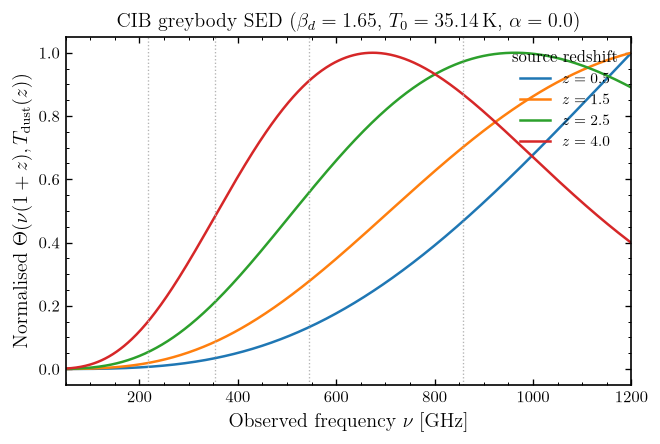

In [ ]:
# Fiducial three-parameter SED (Yang et al. 2026)
BETA_D = 1.65
T0 = 35.14  # K
ALPHA = 0.0  # weak evolution preferred by the fit


def tdust(z, t0=T0, alpha=ALPHA):
    return t0 * (1.0 + z) ** alpha


def theta_nu(nu_ghz, t_dust, beta_d=BETA_D):
    """Greybody SED Θ(ν, T) ∝ ν^{β+3} / (e^{hν/kT}-1), ν in GHz, T in K."""
    nu = np.asarray(nu_ghz, dtype=np.float64)
    x = (const.h * nu * u.GHz / (const.k_B * t_dust * u.K)).to_value(u.dimensionless_unscaled)
    # avoid overflow in exp
    x = np.clip(x, 1e-8, 100.0)
    return (nu ** (beta_d + 3.0)) / np.expm1(x)


def sed_shape_observed(nu_obs_ghz, z, t0=T0, alpha=ALPHA, beta_d=BETA_D):
    """Relative observed-frame specific intensity shape ∝ Θ(ν_rest, T(z)) / χ^2 factor omitted.

    Returns Θ at rest-frame frequency ν_obs*(1+z). Absolute normalisation needs SFR.
    """
    t = tdust(z, t0=t0, alpha=alpha)
    nu_rest = np.asarray(nu_obs_ghz, dtype=np.float64) * (1.0 + z)
    return theta_nu(nu_rest, t, beta_d=beta_d)


# Plot rest-frame / observed SED shapes
nu = np.linspace(50, 1200, 600)
fig, ax = plt.subplots(figsize=(5.6, 3.8))
for z in (0.5, 1.5, 2.5, 4.0):
    s = sed_shape_observed(nu, z)
    s = s / np.nanmax(s)
    ax.plot(nu, s, lw=1.5, label=rf"$z={z}$")

for b in RELEASED_BANDS:
    ax.axvline(b, color="0.7", lw=0.8, ls=":")

ax.set_xlabel(r"Observed frequency $\nu\;[\mathrm{GHz}]$")
ax.set_ylabel(r"Normalised $\Theta\big(\nu(1+z),T_{\mathrm{dust}}(z)\big)$")
ax.set_title(
    rf"CIB greybody SED ($\beta_d={BETA_D}$, $T_0={T0}\,\mathrm{{K}}$, $\alpha={ALPHA}$)"
)
ax.set_xlim(50, 1200)
ax.legend(title=r"source redshift", loc="upper right")
fig.tight_layout()
fig.savefig(OUT_DIR / "cib_sed_shapes.pdf")
fig.savefig(OUT_DIR / "cib_sed_shapes.png")
plt.show()

## 2. Intensity $\leftrightarrow$ thermodynamic temperature

Released maps are CIB specific intensity $I_\nu$ in $\mathrm{Jy\,sr^{-1}}$ (monopoles
$\sim 10^4$–$10^6\,\mathrm{Jy\,sr^{-1}}$ match Planck-scale CIB levels).

Thermodynamic CMB units:

$$
\Delta T
=
\frac{I_\nu}{\mathrm{d}B_\nu/\mathrm{d}T\big|_{T_\mathrm{CMB}}}
\quad[\mathrm{K}],
$$

with

$$
\frac{\mathrm{d}B_\nu}{\mathrm{d}T}
=
\frac{2k_B\nu^2}{c^2}
\frac{x^2 e^x}{(e^x-1)^2},
\qquad
x=\frac{h\nu}{k_B T_\mathrm{CMB}}.
$$

We evaluate this at the **band centre** (maps are already bandpass-convolved in intensity).

In [ ]:
def dB_dT_Jy_per_sr_per_K(nu_ghz: float, t_cmb: float = T_CMB) -> float:
    """dB_ν/dT at T_CMB in Jy/sr/K for monochromatic frequency nu_ghz."""
    nu = nu_ghz * u.GHz
    T = t_cmb * u.K
    x = (const.h * nu / (const.k_B * T)).to_value(u.dimensionless_unscaled)
    # 2 k ν^2 / c^2 * x^2 e^x / (e^x-1)^2  → numerical SI (implicit /sr), then Jy
    prefactor_si = (2.0 * const.k_B * nu**2 / const.c**2).to_value(
        u.W / u.m**2 / u.Hz / u.K
    )
    dBdT_si = prefactor_si * (x**2 * np.exp(x) / np.expm1(x) ** 2)  # W/m^2/Hz/K (/sr)
    return dBdT_si / 1e-26  # Jy/sr/K  (1 Jy = 1e-26 W/m^2/Hz)


def intensity_to_uK(I_Jy_sr: np.ndarray, nu_ghz: float, t_cmb: float = T_CMB) -> np.ndarray:
    """Convert specific intensity [Jy/sr] to thermodynamic μK_CMB."""
    return I_Jy_sr / dB_dT_Jy_per_sr_per_K(nu_ghz, t_cmb=t_cmb) * 1.0e6


print(f"{'ν [GHz]':>8s}  {'dB/dT [Jy/sr/K]':>18s}")
for nu in sorted(RELEASED_BANDS):
    print(f"{nu:8.0f}  {dB_dT_Jy_per_sr_per_K(nu):18.4e}")

 ν [GHz]     dB/dT [Jy/sr/K]
     217          4.8364e+08
     353          2.9665e+08
     545          5.7117e+07
     857          1.4357e+06


## 3. Load released CIB maps and convert to $\mu\mathrm{K}_\mathrm{CMB}$

In [ ]:
def load_cib_intensity(nu_ghz: int) -> np.ndarray:
    path = DATA_DIR / RELEASED_BANDS[nu_ghz]
    with h5py.File(path, "r") as f:
        m = f["data"][:].astype(np.float64)
    if m.size != 12 * NSIDE_FULL**2:
        raise ValueError(f"{path.name}: unexpected size {m.size}")
    if USE_DOWNGRADE:
        m = hp.ud_grade(m, NSIDE)
    return m


cib_I = {}   # Jy/sr
cib_T = {}   # uK_CMB

for nu in sorted(RELEASED_BANDS):
    print(f"Loading {nu} GHz...")
    I = load_cib_intensity(nu)
    T = intensity_to_uK(I, nu)
    cib_I[nu] = I
    cib_T[nu] = T
    print(
        f"  I: mean={I.mean():.4e} Jy/sr, std={I.std():.4e}"
        f"  |  ΔT: mean={T.mean():.4e} μK, std={T.std():.4e} μK"
    )

Loading 217 GHz...


  I: mean=4.2928e+04 Jy/sr, std=3.2522e+03  |  ΔT: mean=8.8759e+01 μK, std=6.7244e+00 μK
Loading 353 GHz...


  I: mean=1.7042e+05 Jy/sr, std=1.2475e+04  |  ΔT: mean=5.7447e+02 μK, std=4.2051e+01 μK
Loading 545 GHz...


  I: mean=4.6901e+05 Jy/sr, std=3.3106e+04  |  ΔT: mean=8.2114e+03 μK, std=5.7962e+02 μK
Loading 857 GHz...


  I: mean=9.4807e+05 Jy/sr, std=6.5846e+04  |  ΔT: mean=6.6035e+05 μK, std=4.5862e+04 μK


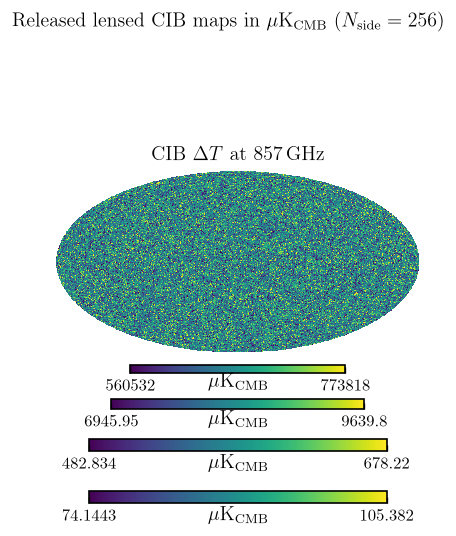

In [ ]:
for i, nu in enumerate(sorted(RELEASED_BANDS), start=1):
    m = cib_T[nu]
    # CIB is positive-definite on average; show from ~percentile floor
    vmin, vmax = np.percentile(m, [1, 99])
    hp.mollview(
        m,
        title=rf"CIB $\Delta T$ at ${nu}\,\mathrm{{GHz}}$",
        unit=r"$\mu\mathrm{K}_\mathrm{CMB}$",
        min=vmin,
        max=vmax,
        sub=(2, 2, i),
        hold=True,
    )

plt.suptitle(
    rf"Released lensed CIB maps in $\mu\mathrm{{K}}_\mathrm{{CMB}}$ "
    rf"($N_{{\mathrm{{side}}}}={NSIDE}$)",
    y=1.02,
)
fig = plt.gcf()
fig.savefig(OUT_DIR / f"cib_released_uK_mollview_nside{NSIDE}.pdf")
fig.savefig(OUT_DIR / f"cib_released_uK_mollview_nside{NSIDE}.png")
plt.show()

## 4. Approximate maps at other frequencies

Because of **frequency decorrelation**, scaling one map is inexact. We use:

| Case | Method |
|------|--------|
| $\nu$ equals a released band | use that map |
| $\nu$ between two released bands | log-frequency interpolation of $I_\nu$ |
| $\nu$ outside $[217,857]\,\mathrm{GHz}$ | scale nearest band by greybody ratio at $z_\mathrm{eff}$ |

Interpolation in intensity:

$$
\log I(\nu)
=
w\log I(\nu_a)+(1-w)\log I(\nu_b),
\quad
w=\frac{\log(\nu_b/\nu)}{\log(\nu_b/\nu_a)}.
$$

Out-of-band scaling from nearest band $\nu_0$:

$$
I(\nu)
\approx
I(\nu_0)\,
\frac{\Theta\big(\nu(1+z_\mathrm{eff}),T(z_\mathrm{eff})\big)}
{\Theta\big(\nu_0(1+z_\mathrm{eff}),T(z_\mathrm{eff})\big)}.
$$

In [ ]:
def sed_ratio(nu_tgt, nu_ref, z_eff=Z_EFF):
    """Θ(ν_tgt)/Θ(ν_ref) at effective redshift z_eff (observed-frame ν)."""
    s_t = sed_shape_observed(nu_tgt, z_eff)
    s_r = sed_shape_observed(nu_ref, z_eff)
    return float(s_t / s_r)


def approximate_cib_intensity(nu_ghz: float) -> tuple[np.ndarray, str]:
    """Return I_ν [Jy/sr] and a short method tag."""
    bands = np.array(sorted(cib_I.keys()), dtype=float)

    # Exact released band (within 0.5 GHz)
    for b in bands:
        if abs(nu_ghz - b) < 0.5:
            return cib_I[int(b)].copy(), f"released {int(b)} GHz"

    # Between two bands: log-frequency interpolation
    if bands.min() < nu_ghz < bands.max():
        i = np.searchsorted(bands, nu_ghz)
        nu_a, nu_b = bands[i - 1], bands[i]
        w = np.log(nu_b / nu_ghz) / np.log(nu_b / nu_a)
        # Allow small negatives from lensing; offset for log interp then restore mean
        Ia, Ib = cib_I[int(nu_a)], cib_I[int(nu_b)]
        floor = 1e-3  # Jy/sr
        logI = w * np.log(np.clip(Ia, floor, None)) + (1.0 - w) * np.log(np.clip(Ib, floor, None))
        I = np.exp(logI)
        # Preserve a sensible mean using SED-weighted means
        return I, f"log-interp {nu_a:.0f}-{nu_b:.0f} GHz (w={w:.3f})"

    # Outside: scale nearest band with effective-z SED
    nu_ref = float(bands[np.argmin(np.abs(bands - nu_ghz))])
    ratio = sed_ratio(nu_ghz, nu_ref, z_eff=Z_EFF)
    I = cib_I[int(nu_ref)] * ratio
    return I, f"SED scale from {nu_ref:.0f} GHz at z_eff={Z_EFF} (x{ratio:.3f})"


# Build requested extra frequencies + keep released ones
target_freqs = sorted(set(RELEASED_BANDS) | set(EXTRA_FREQUENCIES_GHZ))
cib_I_all = dict(cib_I)
cib_T_all = dict(cib_T)
methods = {nu: f"released {nu} GHz" for nu in cib_I}

for nu in target_freqs:
    if nu in cib_I_all:
        continue
    I, method = approximate_cib_intensity(nu)
    T = intensity_to_uK(I, nu)
    cib_I_all[nu] = I
    cib_T_all[nu] = T
    methods[nu] = method
    print(f"{nu:6.1f} GHz: {method}")
    print(f"         I mean={I.mean():.4e} Jy/sr | ΔT mean={T.mean():.4e} μK")

 100.0 GHz: SED scale from 217 GHz at z_eff=1.5 (x0.074)
         I mean=3.1564e+03 Jy/sr | ΔT mean=1.3218e+01 μK
 143.0 GHz: SED scale from 217 GHz at z_eff=1.5 (x0.251)
         I mean=1.0767e+04 Jy/sr | ΔT mean=2.8339e+01 μK
 150.0 GHz: SED scale from 217 GHz at z_eff=1.5 (x0.295)
         I mean=1.2654e+04 Jy/sr | ΔT mean=3.1755e+01 μK
 280.0 GHz: log-interp 217-353 GHz (w=0.476)
         I mean=8.8391e+04 Jy/sr | ΔT mean=2.0597e+02 μK
 600.0 GHz: log-interp 545-857 GHz (w=0.788)
         I mean=5.4462e+05 Jy/sr | ΔT mean=1.7098e+04 μK


## 5. Monopole SED check (released bands)

Compare the sky-averaged intensity spectrum to a single-source greybody at
$z_\mathrm{eff}$ (normalised at 353 GHz). Agreement of the *shape* is only
approximate — the true CIB integrates many redshifts.

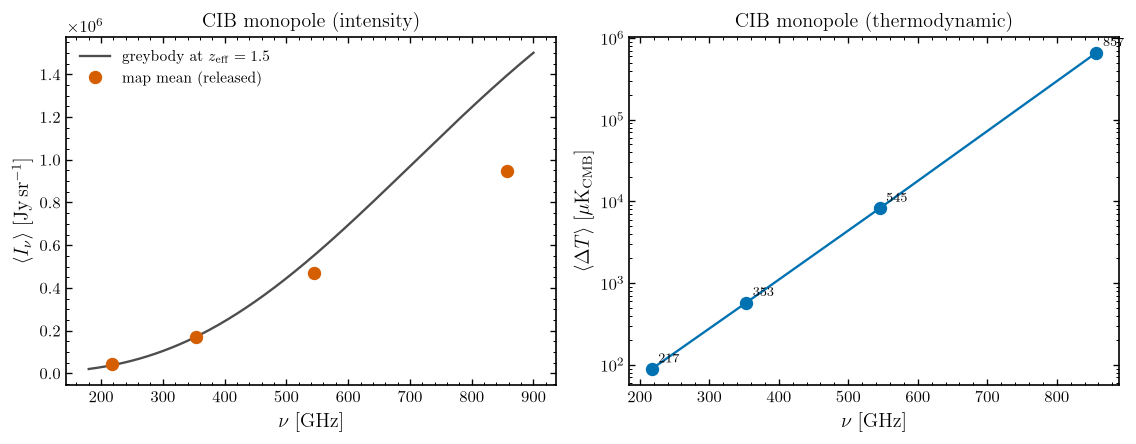

In [ ]:
nus_rel = np.array(sorted(RELEASED_BANDS), dtype=float)
I_mean = np.array([cib_I[int(n)].mean() for n in nus_rel])

# Model shape at z_eff, normalised to 353 GHz mean
nu_fine = np.linspace(180, 900, 400)
shape = sed_shape_observed(nu_fine, Z_EFF)
shape353 = sed_shape_observed(353.0, Z_EFF)
model = shape / shape353 * cib_I[353].mean()

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.8))

ax = axes[0]
ax.plot(nu_fine, model, color="0.3", lw=1.4,
        label=rf"greybody at $z_{{\mathrm{{eff}}}}={Z_EFF}$")
ax.plot(nus_rel, I_mean, "o", color="#D55E00", ms=7, label=r"map mean (released)")
ax.set_xlabel(r"$\nu\;[\mathrm{GHz}]$")
ax.set_ylabel(r"$\langle I_\nu\rangle\;[\mathrm{Jy}\,\mathrm{sr}^{-1}]$")
ax.set_title(r"CIB monopole (intensity)")
ax.legend(loc="upper left")

ax = axes[1]
T_mean = np.array([cib_T[int(n)].mean() for n in nus_rel])
ax.plot(nus_rel, T_mean, "o-", color="#0072B2", ms=7, lw=1.4)
for n, t in zip(nus_rel, T_mean):
    ax.annotate(rf"${n:.0f}$", (n, t), textcoords="offset points", xytext=(4, 4), fontsize=8)
ax.set_yscale("log")
ax.set_xlabel(r"$\nu\;[\mathrm{GHz}]$")
ax.set_ylabel(r"$\langle\Delta T\rangle\;[\mu\mathrm{K}_\mathrm{CMB}]$")
ax.set_title(r"CIB monopole (thermodynamic)")

fig.tight_layout()
fig.savefig(OUT_DIR / f"cib_monopole_SED_nside{NSIDE}.pdf")
fig.savefig(OUT_DIR / f"cib_monopole_SED_nside{NSIDE}.png")
plt.show()

## 6. Gallery of approximate extra-frequency maps

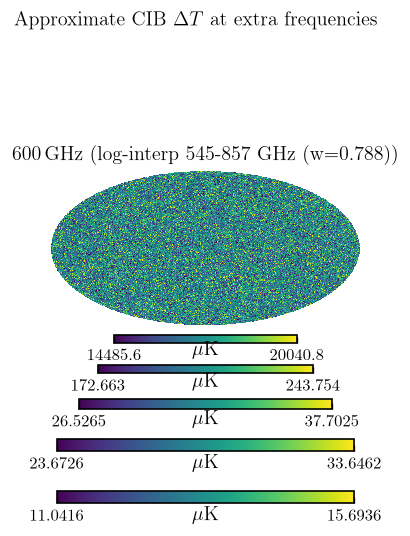

Method summary:
    100.0 GHz: SED scale from 217 GHz at z_eff=1.5 (x0.074)
    143.0 GHz: SED scale from 217 GHz at z_eff=1.5 (x0.251)
    150.0 GHz: SED scale from 217 GHz at z_eff=1.5 (x0.295)
    217.0 GHz: released 217 GHz
    280.0 GHz: log-interp 217-353 GHz (w=0.476)
    353.0 GHz: released 353 GHz
    545.0 GHz: released 545 GHz
    600.0 GHz: log-interp 545-857 GHz (w=0.788)
    857.0 GHz: released 857 GHz


In [ ]:
extra = [nu for nu in EXTRA_FREQUENCIES_GHZ if nu not in RELEASED_BANDS]
n = len(extra)
ncols = min(3, n)
nrows = int(np.ceil(n / ncols))

for i, nu in enumerate(extra, start=1):
    m = cib_T_all[nu]
    vmin, vmax = np.percentile(m, [1, 99])
    hp.mollview(
        m,
        title=rf"{nu:.0f}\,GHz ({methods[nu]})",
        unit=r"$\mu\mathrm{K}$",
        min=vmin,
        max=vmax,
        sub=(nrows, ncols, i),
        hold=True,
    )

plt.suptitle(r"Approximate CIB $\Delta T$ at extra frequencies", y=1.02)
fig = plt.gcf()
fig.savefig(OUT_DIR / f"cib_extra_uK_mollview_nside{NSIDE}.pdf")
fig.savefig(OUT_DIR / f"cib_extra_uK_mollview_nside{NSIDE}.png")
plt.show()

print("Method summary:")
for nu in sorted(methods):
    print(f"  {nu:7.1f} GHz: {methods[nu]}")

## 7. Save maps

Saves both intensity ($\mathrm{Jy\,sr^{-1}}$) and thermodynamic ($\mu\mathrm{K}_\mathrm{CMB}$)
HEALPix FITS for every target frequency.

In [ ]:
tag = f"nside{NSIDE}"
saved = []
# Full Nside=4096 float64 I+T would need ~29 GB; disk is tight → write μK float32 only.
WRITE_INTENSITY = NSIDE <= 512
OUT_DTYPE = np.float32 if NSIDE > 512 else np.float64

for nu in sorted(cib_T_all):
    path_T = OUT_DIR / f"CIB_deltaT_{nu:.0f}GHz_{tag}.fits"
    approx = nu not in RELEASED_BANDS
    method_ascii = methods[nu][:60].encode("ascii", "replace").decode("ascii")

    hp.write_map(
        path_T,
        np.asarray(cib_T_all[nu], dtype=OUT_DTYPE),
        overwrite=True,
        dtype=OUT_DTYPE,
        column_names=["TEMPERATURE"],
        extra_header=[
            ("UNIT", "uK_CMB"),
            ("FREQ", float(nu), "GHz"),
            ("TCMB", float(T_CMB), "K"),
            ("APPROX", int(approx), "1 if not an official released band"),
            ("METHOD", method_ascii),
        ],
    )
    saved.append(path_T)

    if WRITE_INTENSITY:
        path_I = OUT_DIR / f"CIB_I_{nu:.0f}GHz_{tag}.fits"
        hp.write_map(
            path_I,
            np.asarray(cib_I_all[nu], dtype=OUT_DTYPE),
            overwrite=True,
            dtype=OUT_DTYPE,
            column_names=["INTENSITY"],
            extra_header=[
                ("UNIT", "Jy/sr"),
                ("FREQ", float(nu), "GHz"),
                ("APPROX", int(approx)),
                ("METHOD", method_ascii),
            ],
        )
        saved.append(path_I)

print(f"Wrote (dtype={OUT_DTYPE.__name__}, intensity={WRITE_INTENSITY}):")
for pth in saved:
    print(f"  {pth}  ({pth.stat().st_size/1e9:.2f} GB)")


Wrote:
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/CIB_deltaT_100GHz_nside256.fits
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/CIB_I_100GHz_nside256.fits
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/CIB_deltaT_143GHz_nside256.fits
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/CIB_I_143GHz_nside256.fits
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/CIB_deltaT_150GHz_nside256.fits
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/CIB_I_150GHz_nside256.fits
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/CIB_deltaT_

## Notes / limitations

1. **Official bands (217/353/545/857 GHz)** are the only maps that are fully consistent
   with Yang et al.'s shell-by-shell, bandpass-convolved, lensed CIB pipeline.
2. **Interpolated / SED-scaled maps** ignore frequency decorrelation of small-scale
   structure. Fine for rough multi-frequency coadds; not for precision CIB science.
3. **To do it properly at a new $\nu$**: start from SFR shell maps, apply
   $\Theta(\nu,T_\mathrm{dust}(z))$ + Planck bandpass, stack to $z=4.5$, then lens
   shell-by-shell with cumulative $\kappa$ (as in Yang et al. §3.5–3.7).
4. **Next step**: coadd lensed primary CMB + tSZ($\nu$) + kSZ + CIB($\nu$) into
   multi-frequency sky maps in $\mu\mathrm{K}_\mathrm{CMB}$.

### References

1. Yang et al. (2026), MNRAS 548 — §3.5 CIB model, Fig. 1 SED constraints
2. Planck Collaboration XV (2016a) — greybody CIB SED
3. Lenz, Doré & Lagache (2019) — CIB power spectra used for the fit
4. Kennicutt (1998) — SFR–$L_\mathrm{IR}$ conversion